# CS412 - Machine Learning - 2024-2025
## Homework 4


## Dataset
[**CelebA**](https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html) is a large-scale face attributes dataset with more than 200K celebrity images, each with 40 attribute annotations. The images in this dataset cover large pose variations and background clutter.

**Download the data from Sucourse and upload it to your Google Drive. You must upload both CelebA30k.zip and CelebA30k.csv to your Drive without renaming them.
CelebA30k is a smaller version of the original CelebA dataset, containing 30,000 images, to reduce computation time during training.
Split the data as follows: reserve 10% of the samples for validation and 10% for testing (i.e., 3,000 samples). The remaining 80% should be used for training.
Important: The test set (3,000 samples) must be used only for final evaluation and not for model selection or hyperparameter tuning.**

## Task

Build a gender classifier using the PyTorch library and a pretrained VGG-16 model on the CelebA dataset. Your goal is to complete the given code without changing the base architecture of VGG-16 (other than replacing the classification head suitable for binary classification).

You will:
- Freeze the convolutional layers of the pretrained model  
- Replace the classifier head with your own binary classification layer  
- Fine-tune the model on the given subset of CelebA  
- Experiment with different values of learning rate, batch size, and number of epochs  

**Dataset:** CelebA  
**Model:** VGG-16
**Library:** PyTorch  

---

## Software

You will use the PyTorch framework for this homework. PyTorch offers flexible tools for deep learning, including pretrained models, custom training loops, and GPU acceleration.

## 1) Initialize

*   First make a copy of the notebook given to you as a starter.

*   Make sure you change your runtime to GPU.

## 2) Load training dataset

In [1]:
# load data
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
# Import necessary libraries

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, models, transforms

from torch.utils.data import DataLoader, Dataset

# For reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%matplotlib inline

In [3]:
data = pd.read_csv('/content/drive/My Drive/Courses/CS/CS412/CS412-HW4/CelebA30k.csv') # enter the file path on your drive for the csv file
data.head()

,filename,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [4]:
gender_data = data[['filename', 'Male']].copy()
gender_data.head()

,filename,Male
0,000001.jpg,-1
1,000002.jpg,-1
2,000003.jpg,1
3,000004.jpg,-1
4,000005.jpg,-1


In [5]:
# This will extract the contents of the zip file into a folder named data
# Do not extract the zip into your google drive

!unzip "/content/drive/My Drive/Courses/CS/CS412/CS412-HW4/CelebA30k.zip" -d "/content/data"

Görüntülenen çıkış son 5000 satıra kısaltıldı.
  inflating: /content/data/CelebA30k/027646.jpg  
  inflating: /content/data/CelebA30k/007596.jpg  
  inflating: /content/data/CelebA30k/028575.jpg  
  inflating: /content/data/CelebA30k/024367.jpg  
  inflating: /content/data/CelebA30k/023408.jpg  
  inflating: /content/data/CelebA30k/022716.jpg  
  inflating: /content/data/CelebA30k/025079.jpg  
  inflating: /content/data/CelebA30k/003900.jpg  
  inflating: /content/data/CelebA30k/017975.jpg  
  inflating: /content/data/CelebA30k/029643.jpg  
  inflating: /content/data/CelebA30k/026570.jpg  
  inflating: /content/data/CelebA30k/009593.jpg  
  inflating: /content/data/CelebA30k/019780.jpg  
  inflating: /content/data/CelebA30k/008855.jpg  
  inflating: /content/data/CelebA30k/006878.jpg  
  inflating: /content/data/CelebA30k/020101.jpg  
  inflating: /content/data/CelebA30k/019958.jpg  
  inflating: /content/data/CelebA30k/027108.jpg  
  inflating: /content/data/CelebA30k/001871.jpg  
  i

In [6]:
first_image_path = os.path.join("/content/data/CelebA30k/", gender_data.loc[0,"filename"])
img = Image.open(first_image_path)

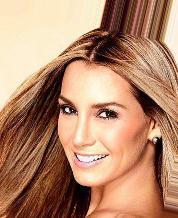

In [7]:
img

# Starting here, you’ll need to fill in the code cells on your own.

## 3) Visualizing/Understanding the dataset

- Display five random images together with their labels

- Display statistics about the dataset, such as distribution of labels, etc.


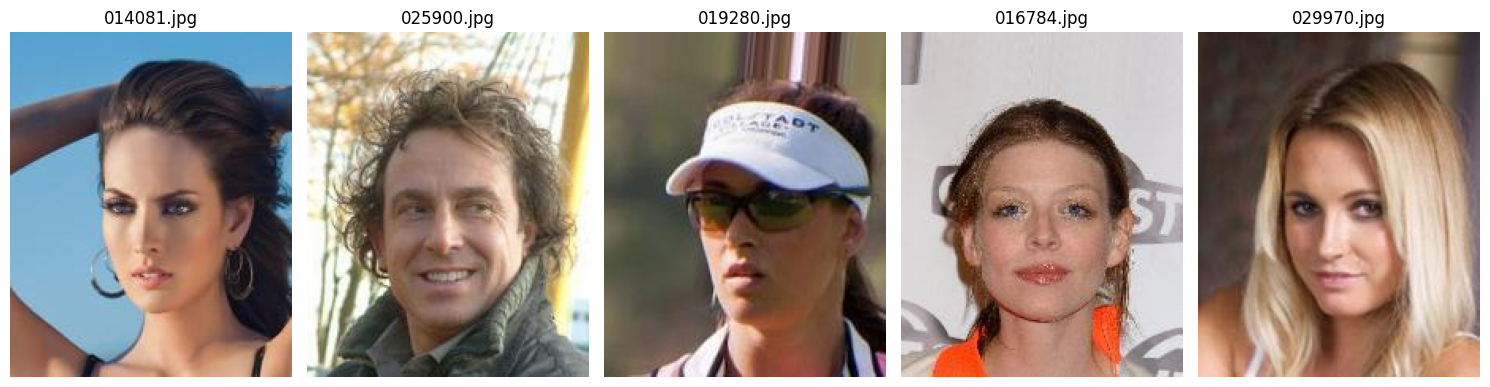

In [9]:
image_path = "/content/data/CelebA30k/"

image_files = [os.path.join(root, file)
               for root, _, files in os.walk(image_path)
               for file in files
               if file.lower().endswith(".jpg")]

random_images = np.random.choice(image_files, size=5, replace=False)

plt.figure(figsize=(15, 5))

for i, img_path in enumerate(random_images):
    img = Image.open(img_path)
    img.thumbnail((300, 300))

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(os.path.basename(img_path))

plt.tight_layout()
plt.show()

Total images in CSV: 30000
Attribute distribution (number of images with attribute = 1):
No_Beard               24957
Young                  23380
Attractive             15390
Mouth_Slightly_Open    14288
Smiling                14259
Wearing_Lipstick       14008
High_Cheekbones        13452
Male                   12680
Heavy_Makeup           11452
Wavy_Hair               9500
Oval_Face               8385
Pointy_Nose             8269
Arched_Eyebrows         7898
Black_Hair              7242
Big_Lips                7142
Big_Nose                7125
Straight_Hair           6307
Brown_Hair              6128
Bags_Under_Eyes         6122
Wearing_Earrings        5563
Bangs                   4571
Blond_Hair              4401
Bushy_Eyebrows          4301
Wearing_Necklace        3590
Narrow_Eyes             3534
5_o_Clock_Shadow        3375
Receding_Hairline       2376
Wearing_Necktie         2246
Eyeglasses              1946
Goatee                  1900
Rosy_Cheeks             1889
Chubby      

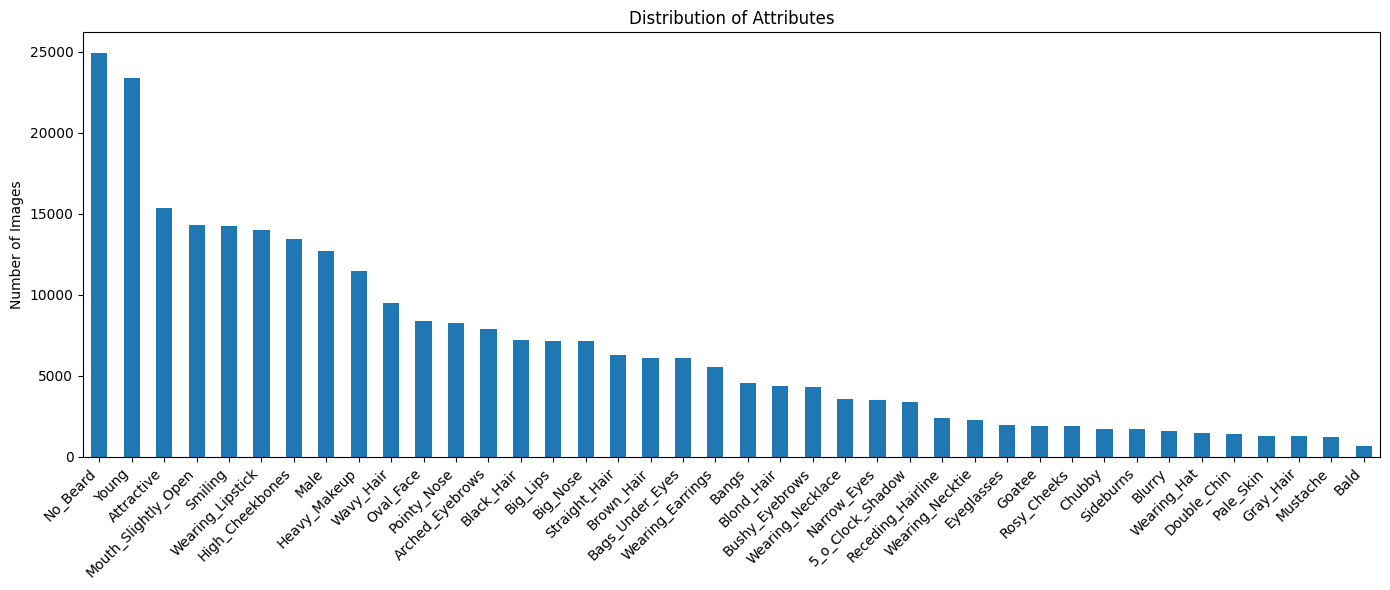

In [10]:
csv_path = '/content/drive/My Drive/Courses/CS/CS412/CS412-HW4/CelebA30k.csv'

df = pd.read_csv(csv_path)
labels = df.drop(columns=['filename']).replace(-1, 0)
df['Male'] = df['Male'].replace(-1, 0)

attribute_counts = labels.sum().sort_values(ascending=False)

print(f"Total images in CSV: {len(df)}")
print("Attribute distribution (number of images with attribute = 1):")
print(attribute_counts)

plt.figure(figsize=(14, 6))
attribute_counts.plot(kind='bar')
plt.title("Distribution of Attributes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4) Split the dataset as train (80%), validation (10%) and test (10%) set.

In [11]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

print(f"Total images: {len(df)}")
print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test: {len(test_df)}")

Total images: 30000
Train: 24000
Validation: 3000
Test: 3000


## 5) Preparing the Data

In this section, you will implement the dataset loading and preprocessing pipeline using PyTorch.

You are provided with:
- `train_df` and `val_df` dataframes, which include two columns: `filename`  and `Male`
- A directory path (`/content/data/CelebA30k`) that contains the image files

Your task is to:
1. Define appropriate transformations using `torchvision.transforms` for the training and validation sets
   - Resize images to 224x224
   - Convert them to tensors
   - Normalize them (you can use `[0.5], [0.5]` for simplicity)
   - Add data augmentation (e.g., horizontal flip) for training
2. Write a custom `Dataset` class that reads images and labels from the dataframe
3. Create `DataLoader` objects for training and validation with an appropriate batch size

In [12]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [13]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'filename']
        img_path = os.path.join(self.image_dir, img_name)

        image = Image.open(img_path).convert('RGB')

        label = torch.tensor(self.df.loc[idx, 'Male'], dtype=torch.float32)
        label = label.unsqueeze(0)

        if self.transform:
            image = self.transform(image)

        return image, label

In [14]:
train_dataset = CustomImageDataset(train_df, image_path, transform=train_transforms)
val_dataset = CustomImageDataset(val_df, image_path, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)

## 6) Transfer Learning with VGG-16

We will create the base model from the well-known VGG-16 architecture available in torchvision.models. This model is pretrained on the ImageNet dataset, a large dataset containing 1.4 million images and 1,000 object categories.

In transfer learning, we use the convolutional base of the pretrained model as a feature extractor. However, we do not use the last fully connected layer, which is specific to ImageNet’s 1,000-class classification task. Instead, we will:
- Keep the convolutional layers (which extract general visual features)
- Remove the final classification layer
- Replace it with our own binary classifier (for gender classification)

This is a common strategy because the layer before the original classification head (the so-called "bottleneck layer") retains high-level, general features useful for a wide range of vision tasks.

### Instructions

You should:
1. Load the VGG-16 model with pretrained=True from torchvision.models.
2. Replace the classifier head with a new sequence of layers suitable for binary classification:
   - The final output should have one neuron (output dimension = 1).
   - Do not apply a Sigmoid activation after the output layer, because the loss function you will use internally applies it.


In [15]:
vgg16 = models.vgg16(pretrained=True)

in_features = vgg16.classifier[0].in_features

vgg16.classifier = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 1)
)

vgg16 = vgg16.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 232MB/s]


## 7) Fine-Tuning and Training the Model

Now that your VGG-16 base model is set up with a new binary classification head, it’s time to fine-tune and train it using your `train_loader` and evaluate it using your `val_loader`.

You will:
- Experiment with two different fine-tuning strategies:
  - Freeze all convolutional layers and train only the classifier head.
  - Unfreeze the last convolutional block and the classifier head, and train them.
- Choose an appropriate optimizer (e.g., `torch.optim.SGD` or `Adam`).
- Use `nn.BCEWithLogitsLoss()` as the loss function.
  - Note: Since you are using nn.BCEWithLogitsLoss(), your model's output should not have a Sigmoid activation. This loss function applies the Sigmoid operation internally.
- Implement a training loop that includes validation after each epoch.
- Monitor both training and validation performance across epochs.

Hyperparameter Tuning:
- Try two different learning rates: 0.001 and 0.0001.
- The number of training epochs must be fixed to 10.
- You may adjust batch size depending on available GPU memory, but typically 32 or 64 is suggested.

Finally, you should report:
- Final training and validation accuracy for each configuration.
- A plot showing training and validation loss across epochs.
- A brief discussion comparing the results for different fine-tuning strategies and learning rates, identifying which combination performed best and why.


In [16]:
epochs = 10
learning_rates = [0.001, 0.0001]
batch_size = 64

def freeze_convolutions(model):
  for param in model.features.parameters():
    param.requires_grad = False

def unfreeze_last_block(model):
  for param in model.features[23:].parameters():
    param.requires_grad = True
  for param in model.classifier.parameters():
    param.requires_grad = True

criterion = nn.BCEWithLogitsLoss()

def create_optimizer(model, lr):
  params_to_update = [param for param in model.parameters() if param.requires_grad]
  return optim.Adam(params_to_update, lr=lr)

def train_and_evaluate(model, train_loader, val_loader, epochs, lr):
  optimizer = create_optimizer(model, lr)
  train_losses, val_losses = [], []
  train_accuracies, val_accuracies = [], []

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()

      outputs = model(images)
      outputs = outputs.view(-1)
      labels = labels.view(-1)
      loss = criterion(outputs, labels)
      loss.backward()

      optimizer.step()

      running_loss += loss.item()
      preds = torch.round(torch.sigmoid(outputs))
      correct_train += (preds.squeeze() == labels).sum().item()
      total_train += labels.size(0)

    avg_train_loss = running_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
      for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        outputs = outputs.view(-1)
        labels = labels.view(-1)
        loss = criterion(outputs, labels)

        running_val_loss += loss.item()

        preds = torch.round(torch.sigmoid(outputs))
        correct_val += (preds.squeeze() == labels).sum().item()
        total_val += labels.size(0)

    avg_val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct_val / total_val

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

  return train_losses, val_losses, train_accuracies, val_accuracies

In [17]:
images, labels = next(iter(train_loader))
outputs = vgg16(images.to(device)).view(-1).cpu().detach()
print("Outputs:", outputs[:5])
print("Labels:", labels[:5])

Outputs: tensor([-0.3200, -0.2710, -0.2292, -0.3815, -0.4395])
Labels: tensor([[1.],
        [0.],
        [1.],
        [0.],
        [0.]])


Training with frozen convolutional layers...
Training with learning rate 0.001
Epoch 1/10 | Train Loss: 0.2055, Train Accuracy: 0.9215 | Val Loss: 0.1487, Val Accuracy: 0.9467
Epoch 2/10 | Train Loss: 0.1337, Train Accuracy: 0.9477 | Val Loss: 0.1273, Val Accuracy: 0.9527
Epoch 3/10 | Train Loss: 0.1107, Train Accuracy: 0.9574 | Val Loss: 0.1361, Val Accuracy: 0.9510
Epoch 4/10 | Train Loss: 0.0931, Train Accuracy: 0.9640 | Val Loss: 0.1308, Val Accuracy: 0.9523
Epoch 5/10 | Train Loss: 0.0830, Train Accuracy: 0.9697 | Val Loss: 0.1487, Val Accuracy: 0.9543
Epoch 6/10 | Train Loss: 0.0676, Train Accuracy: 0.9749 | Val Loss: 0.1459, Val Accuracy: 0.9510
Epoch 7/10 | Train Loss: 0.0673, Train Accuracy: 0.9747 | Val Loss: 0.1496, Val Accuracy: 0.9537
Epoch 8/10 | Train Loss: 0.0596, Train Accuracy: 0.9778 | Val Loss: 0.1508, Val Accuracy: 0.9550
Epoch 9/10 | Train Loss: 0.0486, Train Accuracy: 0.9824 | Val Loss: 0.1355, Val Accuracy: 0.9593
Epoch 10/10 | Train Loss: 0.0438, Train Accuracy

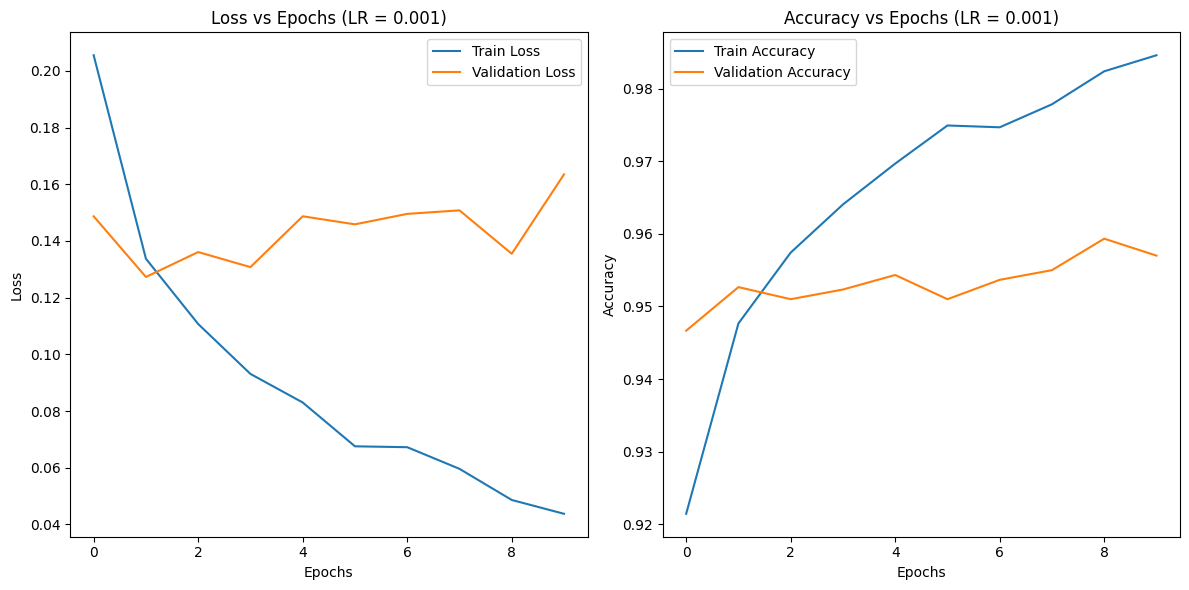

Training with learning rate 0.0001
Epoch 1/10 | Train Loss: 0.0300, Train Accuracy: 0.9898 | Val Loss: 0.1646, Val Accuracy: 0.9627
Epoch 2/10 | Train Loss: 0.0225, Train Accuracy: 0.9921 | Val Loss: 0.1614, Val Accuracy: 0.9620
Epoch 3/10 | Train Loss: 0.0195, Train Accuracy: 0.9931 | Val Loss: 0.1612, Val Accuracy: 0.9620
Epoch 4/10 | Train Loss: 0.0176, Train Accuracy: 0.9944 | Val Loss: 0.1661, Val Accuracy: 0.9610
Epoch 5/10 | Train Loss: 0.0145, Train Accuracy: 0.9952 | Val Loss: 0.1679, Val Accuracy: 0.9623
Epoch 6/10 | Train Loss: 0.0122, Train Accuracy: 0.9958 | Val Loss: 0.1756, Val Accuracy: 0.9620
Epoch 7/10 | Train Loss: 0.0133, Train Accuracy: 0.9960 | Val Loss: 0.1700, Val Accuracy: 0.9617
Epoch 8/10 | Train Loss: 0.0117, Train Accuracy: 0.9962 | Val Loss: 0.1754, Val Accuracy: 0.9647
Epoch 9/10 | Train Loss: 0.0100, Train Accuracy: 0.9972 | Val Loss: 0.1746, Val Accuracy: 0.9630
Epoch 10/10 | Train Loss: 0.0089, Train Accuracy: 0.9973 | Val Loss: 0.1803, Val Accuracy: 0

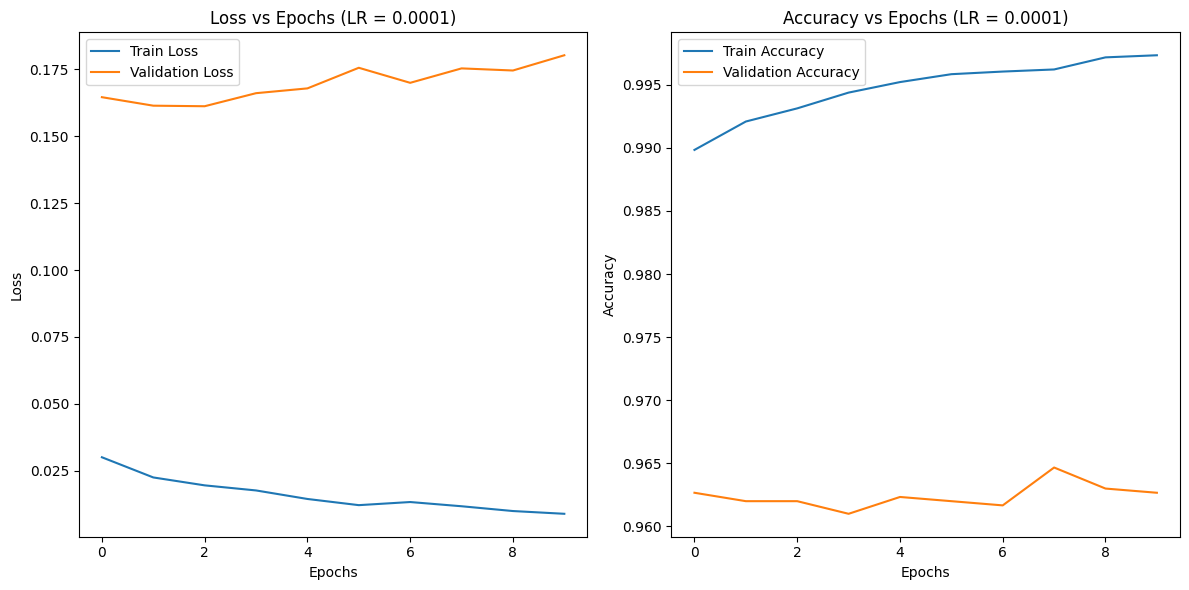

Training with unfreezing last block and classifier head...
Training with learning rate 0.001
Epoch 1/10 | Train Loss: 0.4623, Train Accuracy: 0.9089 | Val Loss: 0.1163, Val Accuracy: 0.9580
Epoch 2/10 | Train Loss: 0.1135, Train Accuracy: 0.9595 | Val Loss: 0.1020, Val Accuracy: 0.9710
Epoch 3/10 | Train Loss: 0.0916, Train Accuracy: 0.9664 | Val Loss: 0.0956, Val Accuracy: 0.9690
Epoch 4/10 | Train Loss: 0.0661, Train Accuracy: 0.9760 | Val Loss: 0.0825, Val Accuracy: 0.9737
Epoch 5/10 | Train Loss: 0.0553, Train Accuracy: 0.9804 | Val Loss: 0.1282, Val Accuracy: 0.9683
Epoch 6/10 | Train Loss: 0.0593, Train Accuracy: 0.9783 | Val Loss: 0.0837, Val Accuracy: 0.9723
Epoch 7/10 | Train Loss: 0.0453, Train Accuracy: 0.9839 | Val Loss: 0.0854, Val Accuracy: 0.9777
Epoch 8/10 | Train Loss: 0.0389, Train Accuracy: 0.9873 | Val Loss: 0.1090, Val Accuracy: 0.9693
Epoch 9/10 | Train Loss: 0.0351, Train Accuracy: 0.9878 | Val Loss: 0.1016, Val Accuracy: 0.9743
Epoch 10/10 | Train Loss: 0.0285, 

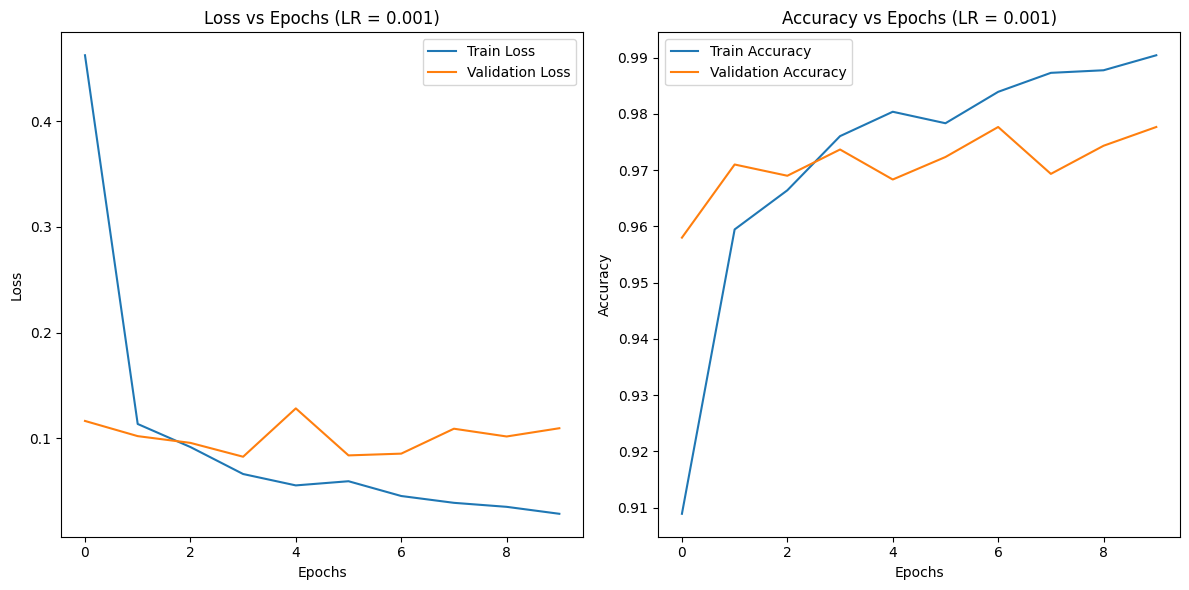

Training with learning rate 0.0001
Epoch 1/10 | Train Loss: 0.0114, Train Accuracy: 0.9963 | Val Loss: 0.1366, Val Accuracy: 0.9757
Epoch 2/10 | Train Loss: 0.0057, Train Accuracy: 0.9985 | Val Loss: 0.1777, Val Accuracy: 0.9763
Epoch 3/10 | Train Loss: 0.0029, Train Accuracy: 0.9990 | Val Loss: 0.2233, Val Accuracy: 0.9723
Epoch 4/10 | Train Loss: 0.0034, Train Accuracy: 0.9989 | Val Loss: 0.2413, Val Accuracy: 0.9743
Epoch 5/10 | Train Loss: 0.0025, Train Accuracy: 0.9993 | Val Loss: 0.2460, Val Accuracy: 0.9763
Epoch 6/10 | Train Loss: 0.0021, Train Accuracy: 0.9995 | Val Loss: 0.2592, Val Accuracy: 0.9740
Epoch 7/10 | Train Loss: 0.0001, Train Accuracy: 1.0000 | Val Loss: 0.3068, Val Accuracy: 0.9760
Epoch 8/10 | Train Loss: 0.0007, Train Accuracy: 0.9998 | Val Loss: 0.2919, Val Accuracy: 0.9773
Epoch 9/10 | Train Loss: 0.0012, Train Accuracy: 0.9995 | Val Loss: 0.3847, Val Accuracy: 0.9700
Epoch 10/10 | Train Loss: 0.0015, Train Accuracy: 0.9995 | Val Loss: 0.2726, Val Accuracy: 0

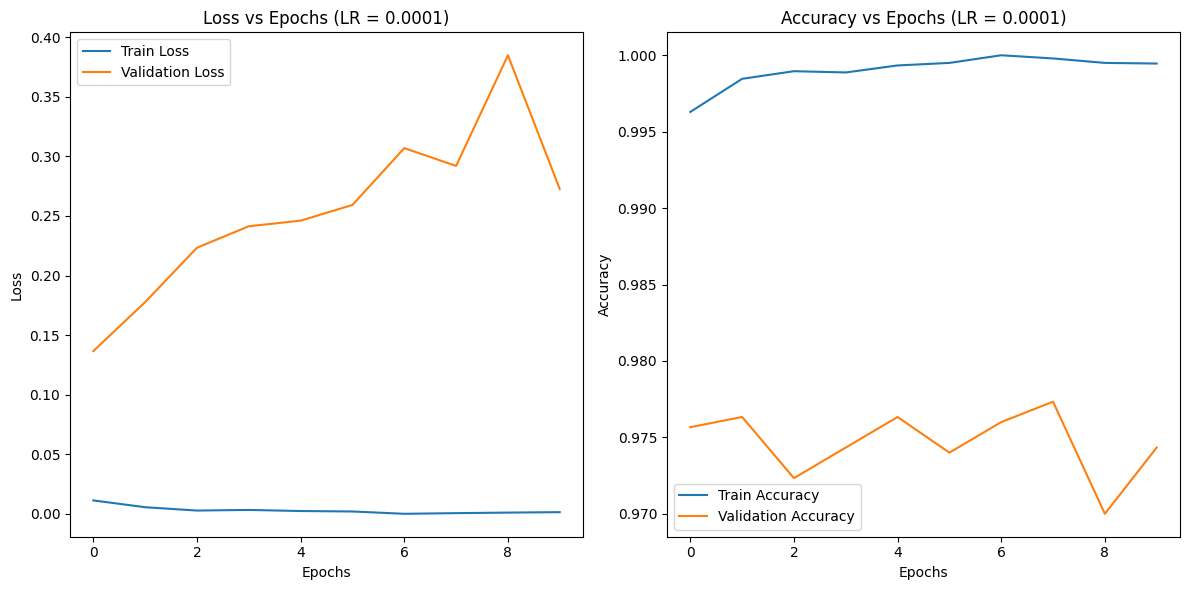

In [18]:
freeze_convolutions(vgg16)
print("Training with frozen convolutional layers...")

for lr in learning_rates:
    print(f"Training with learning rate {lr}")
    train_losses, val_losses, train_accuracies, val_accuracies = train_and_evaluate(
        vgg16, train_loader, val_loader, epochs, lr
    )

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(range(epochs), train_losses, label='Train Loss')
    plt.plot(range(epochs), val_losses, label='Validation Loss')
    plt.title(f"Loss vs Epochs (LR = {lr})")
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(epochs), train_accuracies, label='Train Accuracy')
    plt.plot(range(epochs), val_accuracies, label='Validation Accuracy')
    plt.title(f"Accuracy vs Epochs (LR = {lr})")
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

unfreeze_last_block(vgg16)
print("Training with unfreezing last block and classifier head...")

for lr in learning_rates:
    print(f"Training with learning rate {lr}")
    train_losses, val_losses, train_accuracies, val_accuracies = train_and_evaluate(
        vgg16, train_loader, val_loader, epochs, lr
    )

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(range(epochs), train_losses, label='Train Loss')
    plt.plot(range(epochs), val_losses, label='Validation Loss')
    plt.title(f"Loss vs Epochs (LR = {lr})")
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(epochs), train_accuracies, label='Train Accuracy')
    plt.plot(range(epochs), val_accuracies, label='Validation Accuracy')
    plt.title(f"Accuracy vs Epochs (LR = {lr})")
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

## 8) Test your classifier on Test set

- Use your model to predict the labels of the test set and report the final accuracy.

In [22]:
from sklearn.metrics import accuracy_score

test_dataset = CustomImageDataset(test_df, image_path, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

def test_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            preds = torch.round(torch.sigmoid(outputs))

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy

test_accuracy = test_model(vgg16, test_loader, device)
print(f"Final Test Accuracy: {test_accuracy:.4f}")

Final Test Accuracy: 0.9793
